In [ ]:
from google.colab import files
uploaded = files.upload()

Saving restaurant.csv to restaurant (1).csv


In [ ]:
# PySpark
from pyspark.sql.functions import *
from pyspark.sql.types import *

# Pandas & NumPy & Matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from pyspark.sql import SparkSession

# Create Spark Session
spark = SparkSession.builder \
    .appName("Restaurant ML Case Study") \
    .getOrCreate()
# Load Data
df = spark.read.csv("restaurant.csv", header=True, inferSchema=True)

# Clean
df_clean = df.dropna(subset=["Cuisines", "City"])

df_clean.show(5)

+-------------+--------------------+------------+----------------+--------------------+--------------------+--------------------+----------+---------+--------------------+--------------------+----------------+-----------------+-------------------+-----------------+--------------------+-----------+----------------+------------+-----------+-----+
|Restaurant ID|     Restaurant Name|Country Code|            City|             Address|            Locality|    Locality Verbose| Longitude| Latitude|            Cuisines|Average Cost for two|        Currency|Has Table booking|Has Online delivery|Is delivering now|Switch to order menu|Price range|Aggregate rating|Rating color|Rating text|Votes|
+-------------+--------------------+------------+----------------+--------------------+--------------------+--------------------+----------+---------+--------------------+--------------------+----------------+-----------------+-------------------+-----------------+--------------------+-----------+--------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Convert to Pandas
pdf = df_clean.select(
    "Restaurant Name", "Aggregate rating", "Votes", "City"
).toPandas()
# Convert 'Aggregate rating' to numeric
pdf["Aggregate rating"] = pd.to_numeric(pdf["Aggregate rating"], errors='coerce')
# Weighted Rating
pdf["Weighted_Rating"] = pdf["Aggregate rating"] * np.log1p(pdf["Votes"])
# Top Restaurants
top_hidden = pdf.sort_values("Weighted_Rating", ascending=False)
print(top_hidden.head())

                Restaurant Name  Aggregate rating    Votes       City  \
719                        Toit               4.8  10934.0  Bangalore   
726                    Truffles               4.7   9667.0  Bangalore   
2405            Barbeque Nation               4.9   5966.0    Kolkata   
2298  AB's - Absolute Barbecues               4.9   5434.0  Hyderabad   
730   AB's - Absolute Barbecues               4.6   6907.0  Bangalore   

      Weighted_Rating  
719         44.638675  
726         43.129911  
2405        42.600598  
2298        42.143013  
730         40.666003  


In [ ]:
pdf = df_clean.select(
    "Restaurant Name", "Average Cost for two", "Aggregate rating"
).toPandas()

# Convert 'Average Cost for two' and 'Aggregate rating' to numeric, coercing errors to NaN
pdf["Average Cost for two"] = pd.to_numeric(pdf["Average Cost for two"], errors='coerce')
pdf["Aggregate rating"] = pd.to_numeric(pdf["Aggregate rating"], errors='coerce')

# Drop rows where either of the selected columns is NaN after conversion
pdf = pdf.dropna(subset=["Average Cost for two", "Aggregate rating"])

# Features
X = pdf[["Average Cost for two", "Aggregate rating"]]
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
pdf["Cluster"] = kmeans.fit_predict(X_scaled)
print(pdf.head())

          Restaurant Name  Average Cost for two  Aggregate rating  Cluster
0        Le Petit Souffle                1100.0               4.8        0
1        Izakaya Kikufuji                1200.0               4.5        0
2  Heat - Edsa Shangri-La                4000.0               4.4        0
3                    Ooma                1500.0               4.9        0
4             Sambo Kojin                1500.0               4.8        0


In [ ]:
pdf = df_clean.select(
    "Average Cost for two", "Votes", "Price range"
).dropna().toPandas()

X = pdf[["Average Cost for two", "Votes"]]
y = pdf["Price range"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy*100)

Accuracy: 92.40041928721175


In [ ]:
pdf = df_clean.select(
    "Restaurant Name", "Cuisines", "City"
).toPandas()

# One-hot encoding cuisines
cuisine_matrix = pdf["Cuisines"].str.get_dummies(sep=",")

# Similarity
similarity = cosine_similarity(cuisine_matrix)

# Pick one restaurant
index = 0

scores = list(enumerate(similarity[index]))
scores = sorted(scores, key=lambda x: x[1], reverse=True)

print("Recommended Restaurants:")
for i in scores[1:6]:
    print(pdf.iloc[i[0]]["Restaurant Name"])

Recommended Restaurants:
Paris 6 Classique
Django
Jaan
Rhubarb Le Restaurant
Restaurant Gordon Ramsay


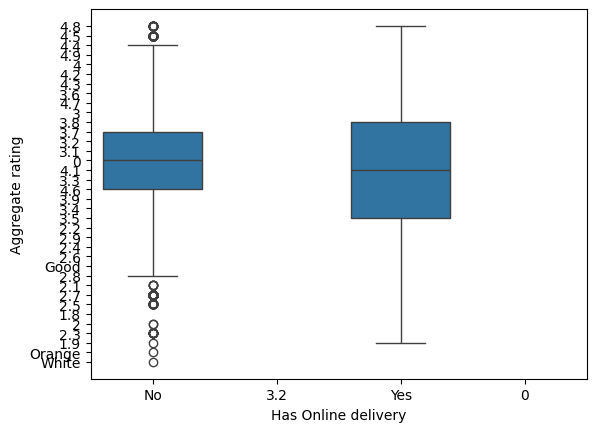

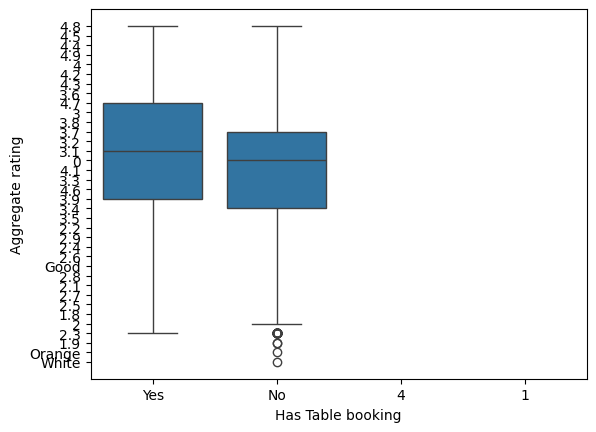

In [ ]:
# Convert PySpark DataFrame to Pandas DataFrame
pdf_plot = df.toPandas()

sns.boxplot(x='Has Online delivery', y='Aggregate rating', data=pdf_plot)
plt.show()
sns.boxplot(x='Has Table booking', y='Aggregate rating', data=pdf_plot)
plt.show()